# Conjunctions with Inequality Propositions

This notebook studies the efficient implementation of support (coverage) and, crucially, implication checks for inequality propositions about ordinal variables. 

With naive binarisation, checking the implications of a conjunction with support count $m$ costs $\Theta(mr)$ where $r$ is the number of propositions not included in the conjunction. For $d$ ordinal variables, $r$ can be up to $dn$, leading to a cost of $\Theta(dn^2)$ conjunctions with large support count. Our goal is to reduce this to $\Theta(dn)$ by directly operating on the underlying numerical data matrix.


## Example Data

We will start the investigation this with the following small random dataset of three variables and five data points.

In [1]:
import numpy as np

RNG = np.random.default_rng(seed=0)
x = RNG.multivariate_normal([0, 0, 0], [[1, 0.5, -0.5],[0.5, 1, -0.5], [-0.5, -0.5, 1]], size=100)
x


array([[ 2.67089894e-01, -3.53584822e-01,  2.21479959e-01],
       [ 1.23116415e-01, -4.57868775e-01, -7.78005984e-02],
       [-1.47101331e+00, -3.88020233e-01,  1.33510120e+00],
       [ 1.05707187e+00,  7.09645291e-01, -1.33291975e+00],
       [ 1.17905266e+00,  2.14864736e+00, -2.36743902e+00],
       [ 4.15277811e-01,  4.17072290e-01, -9.61331273e-01],
       [-4.10304448e-01,  2.22266520e-01,  8.20246849e-01],
       [-9.12768318e-01, -1.54978231e+00,  8.84587632e-01],
       [-1.16693981e+00, -4.76044420e-01,  5.70056717e-01],
       [ 8.79715332e-01,  4.60157849e-01, -9.17883674e-01],
       [ 7.32421193e-01,  7.65726309e-01, -9.74901884e-01],
       [-2.36424041e-01, -4.36856274e-01,  6.51515397e-01],
       [ 9.86477273e-01,  2.42727783e-01, -3.72341417e-01],
       [-3.45317125e-01, -2.28594634e+00,  1.02688081e+00],
       [-9.46219153e-01, -7.84588746e-01,  1.56590015e+00],
       [ 1.38807257e+00,  4.19449413e-01,  1.03857127e+00],
       [-1.26469504e+00, -9.16643667e-01

Text(0, 0.5, '$x_2$')

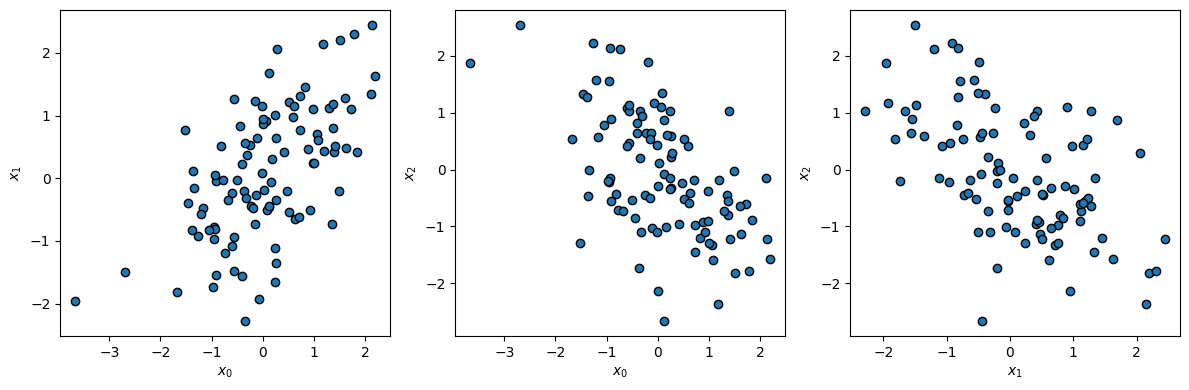

In [2]:
from matplotlib import pyplot as plt

_, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=False)
axs[0].scatter(x[:, 0], x[:, 1], ec='black')
axs[0].set_xlabel('$x_0$')
axs[0].set_ylabel('$x_1$')
axs[1].scatter(x[:, 0], x[:, 2], ec='black')
axs[1].set_xlabel('$x_0$')
axs[1].set_ylabel('$x_2$')
axs[2].scatter(x[:, 1], x[:, 2], ec='black')
axs[2].set_xlabel('$x_1$')
axs[2].set_ylabel('$x_2$')

## Proposition Representation

We generically represent propositons as $sx_j \geq t$ where $s \in \{-1, 1\}$. This way, $x_j \leq t$ is represented as $-x_j \geq -t$. This means that a whole proposition store with $k$ propositions can be represented by $k$-vectors $\boldsymbol{v} \in \{0,\dots, p\}^k$, $\boldsymbol{t} \in \mathbb{R}^k$, and $\boldsymbol{s} \in \{-1, 1\}$. This approach has to be refined to also represent propositions for categorical attributes, as for those there should only be inequality or subset propositions.

The following function creates propositions for variable $j$ all $t \in \{x_{1,j}, \dots, x_{n,j}\}$. Note that this creates empirically trivial propositions for the maximum and minimum values, which should be avoided in a real implementation.

In [3]:
def propositions(x):
    n, p = x.shape
    v = np.repeat(np.arange(p), n)
    t = x.T.flatten()
    s = np.repeat([1, -1], p*n)
    return np.concatenate((v, v)), np.concatenate((t, -t)), s


v, t, s = propositions(x)
v, t, s

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

The following materialises an explicit boolean matrix representation of the propositions for the given data. This is for illustrative purposes only and precisely what we want to avoid for an efficient implementation.

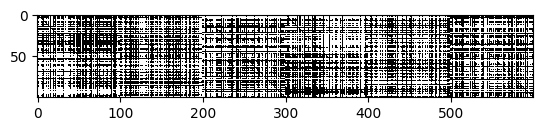

In [4]:
binary = s*x[:, v] >= t
# plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

In [5]:
np.where(binary.sum(axis=0)==len(x))

(array([ 73, 113, 279, 323, 446, 590]),)

In [6]:
def prop_to_string(v, t, s):
    return f'x{v+1} {'>=' if s==1 else '<='} {s*t:.3g}'

#q = np.array([10, 35, 70])
q = np.array([10, 140, 500])

for p in q:
    print(prop_to_string(v[p], t[p], s[p]), np.flatnonzero(binary[:, p]))

x1 >= 0.732 [ 3  4  9 10 12 15 17 18 20 23 25 28 31 33 35 36 42 43 46 53 54 67 69 77
 83 91 97]
x2 >= -0.243 [ 3  4  5  6  9 10 12 15 17 18 21 23 25 26 27 28 30 31 32 33 35 36 37 40
 41 42 43 44 46 48 50 51 52 53 54 55 57 58 61 62 63 66 69 70 72 74 76 77
 78 81 82 83 86 87 88 91 92 94 96 97 98]
x3 <= 0.221 [ 0  1  3  4  5  9 10 12 17 18 19 20 21 23 25 27 28 31 32 33 34 35 36 37
 41 42 43 46 48 49 50 51 52 53 54 55 58 59 60 61 63 66 67 69 72 74 76 77
 78 79 83 87 88 89 91 92 94 95 96 97 98 99]


## Extent / Support Computation

With the binary matrix representation, the extent or support of a conjunction can be found by forming the product of all relevant columns or, alternatively, by summing up all columns and compare the result vector component-wise to the length of the conjunction $l$. The product approach appears to be faster, likely due to the absence of the final comparison step.

In [7]:
np.flatnonzero(np.prod(binary[:, q], axis=1))

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [8]:
np.flatnonzero(np.sum(binary[:, q], axis=1)==len(q))

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [9]:
%timeit np.flatnonzero(np.prod(binary[:, q], axis=1))

2.2 μs ± 37 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [10]:
%timeit np.flatnonzero(np.sum(binary[:, q], axis=1)==len(q))

2.62 μs ± 50.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Without a pre-computed binary matrix representation, we can materialise just the relevant columns of the binary matrix, which of course incurs some extra cost.

In [11]:
np.flatnonzero(np.prod(s[q]*x[:, v[q]] >= t[q], axis=1, dtype=bool))

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [12]:
%timeit np.flatnonzero(np.prod(s[q]*x[:, v[q]] >= t[q], axis=1, dtype=bool))

3.7 μs ± 133 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [13]:
def support(p, x, v, t, s, sup=None):
    sup = sup if sup is not None else np.arange(len(x))
    return sup[s[p]*x[sup, v[p]] >= t[p]]

support(0, x, v, t, s)

array([ 0,  3,  4,  5,  9, 10, 12, 15, 17, 18, 20, 23, 25, 28, 31, 33, 34,
       35, 36, 41, 42, 43, 46, 49, 53, 54, 60, 61, 62, 67, 69, 77, 81, 83,
       86, 91, 97, 98])

In [9]:
# x[np.ix_([0, 1, 2], [0, 2])]

In [14]:
def extended_support(q, x, v, t, s, sup=None):
    sup = sup if sup is not None else np.arange(len(x))
    q = np.atleast_1d(q)
    return sup[np.prod(s[q]*x[np.ix_(sup, v[q])] >= t[q], axis=1, dtype=bool)]

extended_support(q, x, v, t, s)

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [15]:
%timeit extended_support(q, x, v, t, s)

6.48 μs ± 95.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [22]:
from numba import njit

@njit
def extended_support_numba(q, x, v, t, s):
    if len(q)==0:
        return np.arange(len(x))
    
    res = np.flatnonzero(s[q[0]]*x[:, v[q[0]]] >= t[q[0]])
    for i in range(1, len(q)):
        res = res[np.flatnonzero(s[q[i]]*x[res, v[q[i]]] >= t[q[i]])]
    return res

extended_support_numba(q, x, v, t, s)

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [23]:
%timeit extended_support(q, x, v, t, s)

6.53 μs ± 146 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [30]:
@njit
def extended_support_numba(q, x, v, t, s):
    if len(q) == 0:
        return np.arange(x.shape[0])

    res = np.empty(x.shape[0], dtype=np.int64)
    res_len = 0

    # First condition (populate initial res)
    # col0 = x[:, v[q[0]]]
    # for i in range(x.shape[0]):
    #     if s[q[0]] * col0[i] >= t[q[0]]:
    #         res[res_len] = i
    #         res_len += 1

    s0 = s[q[0]]
    v0 = v[q[0]]
    t0 = t[q[0]]
    for i in range(x.shape[0]):
        if s0 * x[i, v0] >= t0:
            res[res_len] = i
            res_len += 1

    # Refine res in-place
    for j in range(1, len(q)):
        vj = v[q[j]]
        tj = t[q[j]]
        sj = s[q[j]]
        k = 0
        for i in range(res_len):
            row = res[i]
            if sj * x[row, vj] >= tj:
                res[k] = row
                k += 1
        res_len = k

    return res[:res_len]

extended_support_numba(q, x, v, t, s)

array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
       53, 54, 69, 77, 83, 91, 97])

In [31]:
%timeit extended_support(q, x, v, t, s)

6.54 μs ± 37.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Intent Computation

Computing the intent of a given extent is symmetric to extent computation if we are working with the explicit binary matrix representation.

In [145]:
ext = np.flatnonzero(np.prod(binary[:, q], axis=1))
np.flatnonzero(np.prod(binary[ext], axis=0))
# binary[ext]

array([  0,   1,   2,   5,   6,   7,   8,  10,  11,  13,  14,  16,  19,
        21,  22,  24,  26,  27,  29,  30,  32,  34,  37,  38,  39,  40,
        41,  44,  45,  47,  48,  49,  50,  51,  52,  55,  56,  57,  58,
        59,  60,  61,  62,  63,  64,  65,  66,  68,  70,  71,  72,  73,
        74,  75,  76,  78,  79,  80,  81,  82,  84,  85,  86,  87,  88,
        89,  90,  92,  93,  94,  95,  96,  98,  99, 100, 101, 102, 107,
       108, 111, 113, 114, 116, 119, 120, 122, 124, 129, 134, 138, 139,
       140, 145, 147, 149, 154, 156, 159, 160, 164, 165, 167, 168, 171,
       173, 175, 179, 180, 184, 185, 189, 190, 193, 195, 199, 204, 279,
       323, 446, 500, 502, 506, 507, 508, 511, 513, 514, 515, 516, 522,
       524, 526, 529, 530, 537, 538, 539, 540, 544, 545, 547, 554, 556,
       557, 558, 562, 564, 565, 568, 570, 571, 573, 575, 580, 581, 582,
       584, 585, 586, 588, 590, 593])

In [146]:
%timeit np.flatnonzero(np.prod(binary[ext], axis=0))

15.2 μs ± 137 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [147]:
q2 = np.array([0])
ext2 = np.flatnonzero(np.prod(binary[:, q2], axis=1))
np.flatnonzero(np.prod(binary[ext2], axis=0))

array([  0,   1,   2,   6,   7,   8,  11,  13,  14,  16,  19,  21,  22,
        24,  26,  27,  29,  30,  32,  37,  38,  39,  40,  44,  45,  47,
        48,  50,  51,  52,  55,  56,  57,  58,  59,  63,  64,  65,  66,
        68,  70,  71,  72,  73,  74,  75,  76,  78,  79,  80,  82,  84,
        85,  87,  88,  89,  90,  92,  93,  94,  95,  96,  99, 107, 113,
       114, 116, 119, 120, 122, 124, 129, 138, 156, 159, 164, 165, 168,
       171, 173, 180, 184, 185, 190, 193, 199, 204, 279, 323, 446, 502,
       514, 515, 516, 522, 526, 529, 539, 540, 545, 556, 570, 573, 575,
       580, 590, 593])

In [148]:
%timeit np.flatnonzero(np.prod(binary[ext2], axis=0))

21.1 μs ± 430 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


By directly working on the underlying numeric data, we can evaluate implication for all $nd$ propositions in time $O(nd)$ by first finding the maximum and minimum of each column and then comparing the threshold of each proposition to the maximum or mininum of the corresponding variable.

In [167]:
# def truth(x, v, t, s, rem=None):
#     rem = rem if rem is not None else np.arange(len(v))
#     l=np.min(x, axis=0)
#     u=np.max(x, axis=0)
    
#     res = np.zeros(len(v[rem]), dtype=bool)
#     np.greater_equal(l[v[rem]], t[rem], where=s[rem]==1, out=res)
#     np.greater_equal(-u[v[rem]], t[rem], where=s[rem]==-1, out=res)
    
#     return np.flatnonzero(res)

# sup = extended_support(q, x, v, t, s)
# closure = truth(x[sup], v, t, s)
# #crit = np.argmax(imps) if np.any(imps) else -1
# sup, closure

def truth(x, v, t, s):
    l=np.min(x, axis=0)
    u=np.max(x, axis=0)
    
    res = np.zeros(len(v), dtype=bool)
    np.greater_equal(l[v], t, where=s==1, out=res)
    np.greater_equal(-u[v], t, where=s==-1, out=res)
    
    return np.flatnonzero(res)

sup = extended_support(q, x, v, t, s)
closure = truth(x[sup], v, t, s)
#crit = np.argmax(imps) if np.any(imps) else -1
sup, closure

(array([ 3,  4,  9, 10, 12, 17, 18, 23, 25, 28, 31, 33, 35, 36, 42, 43, 46,
        53, 54, 69, 77, 83, 91, 97]),
 array([  0,   1,   2,   5,   6,   7,   8,  10,  11,  13,  14,  16,  19,
         21,  22,  24,  26,  27,  29,  30,  32,  34,  37,  38,  39,  40,
         41,  44,  45,  47,  48,  49,  50,  51,  52,  55,  56,  57,  58,
         59,  60,  61,  62,  63,  64,  65,  66,  68,  70,  71,  72,  73,
         74,  75,  76,  78,  79,  80,  81,  82,  84,  85,  86,  87,  88,
         89,  90,  92,  93,  94,  95,  96,  98,  99, 100, 101, 102, 107,
        108, 111, 113, 114, 116, 119, 120, 122, 124, 129, 134, 138, 139,
        140, 145, 147, 149, 154, 156, 159, 160, 164, 165, 167, 168, 171,
        173, 175, 179, 180, 184, 185, 189, 190, 193, 195, 199, 204, 279,
        323, 446, 500, 502, 506, 507, 508, 511, 513, 514, 515, 516, 522,
        524, 526, 529, 530, 537, 538, 539, 540, 544, 545, 547, 554, 556,
        557, 558, 562, 564, 565, 568, 570, 571, 573, 575, 580, 581, 582,
        58

In [168]:
%timeit truth(x[ext], v, t, s)

9.34 μs ± 80.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [169]:
%timeit truth(x[ext2], v, t, s)

9.17 μs ± 16 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Numba Class

Some surprising limitations of numba
- format strings do not work correctly with float64
- axis parameter of np.max and np.min is not supported
- np.ix_ is not suported

In [ ]:
from numba.types import int64, float64
from numba.experimental import jitclass

@jitclass
class Propositionalization:

    v: int64[:]
    t: float64[:]
    s: int64[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    # def test(self, q, x):
    #     return self.s[q][:, None]*x[self.v[q]]

    def extend(self, p, x):
        return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= t[p])
    
    def truth(self, x, rem=None):
        rem = rem if rem is not None else np.arange(len(self.v))
        l=np.min(x, axis=0)
        u=np.max(x, axis=0)
    
        res = np.zeros(len(self.v[rem]), dtype=bool)
        np.greater_equal(l[self.v[rem]], self.t[rem], where=self.s[rem]==1, out=res)
        np.greater_equal(-u[self.v[rem]], self.t[rem], where=self.s[rem]==-1, out=res)
    
        return np.flatnonzero(res)
    
    def implied(self, p, x, l=None, u=None):
        l = np.min(x[:, self.v[p]])
        u = np.max(x[:, self.v[p]])
        if self.s[p]==1:
            return l >= t[p]
        else:
            return -u >= t[p]
        
    def critical(self, q, x):
        j = 0
        for p in q:
            while j < p:
                if self.implied(j, x):
                    return j
                j = j + 1
            j = j + 1
        return -1

def to_string(self, j):
    return f'x{v[j]+1} {'>=' if s[j]==1 else '<='} {s[j]*t[j]:0.3f}'

def make_propositionalization(x):
    n, p = x.shape
    v = np.repeat(np.arange(p), n)
    t = x.T.flatten()
    s = np.repeat([1, -1], p*n)
    return Propositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

props = make_propositionalization(x)
ext = props.extend(0, x)
print(to_string(props, len(props.v)-1))
props.critical(np.array([0, 20]), x[props.extend(20, x)]), props.implied(0, x[props.extend(20, x)])

x3 <= -0.144


(1, True)

In [171]:
-np.inf * np.ones(3)

array([-inf, -inf, -inf])

In [157]:
%timeit props.critical(np.array([20]), x[props.extend(20, x)])

2.33 μs ± 23.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [67]:
x

array([[-0.42909689,  0.21132576, -0.13210486],
       [-0.27164369,  0.08995136, -0.53566937],
       [-0.77742955, -1.48116478,  0.94708096],
       [ 1.07522415,  1.11655013, -0.62327446],
       [ 2.63649119,  1.39058024, -0.21879166],
       [ 0.79231221,  0.47601205, -0.54425898],
       [-0.29221517, -0.42074983,  1.04251337],
       [-1.35914711, -1.00763704, -0.66519467],
       [-0.4106785 , -1.15417775,  0.0940123 ],
       [ 0.68814003,  0.90833515, -0.45772583],
       [ 0.9539675 ,  0.79474249, -0.20917557],
       [-0.64607237, -0.29069966,  0.21465912],
       [ 0.17424445,  0.95821992, -0.12961363],
       [-2.0503112 , -0.53638742, -1.25906553],
       [-1.29779012, -1.03333449,  0.7813114 ],
       [-0.70826403,  1.25199429,  1.45802068],
       [-1.73895177, -1.38157136,  1.31510376],
       [ 0.71819716,  1.3746721 , -0.00445413],
       [ 0.90082191,  1.3306856 ,  0.39512206],
       [-0.2719394 , -0.93364197, -1.18411797],
       [-0.49171993,  1.24764795, -1.169

In [173]:
str(props.s[0]*props.t[0])

'0.2670898939865199'